In [122]:
import pandas as pd

data = {
    "Event_Name": [
        "Tech Fest",
        "AI Workshop",
        "Cultural Fest",
        "Coding Workshop",
        "Sports Day",
        "Tech Fest",
        "AI Workshop",
        "Cultural Fest",
        "Coding Workshop",
        "Sports Day"
    ],
    "Event_Type": [
        "Technical",
        "Workshop",
        "Cultural",
        "Workshop",
        "Sports",
        "Technical",
        "Workshop",
        "Cultural",
        "Workshop",
        "Sports"
    ],
    "Department": [
        "CSE",
        "CSE",
        "ECE",
        "IT",
        "MECH",
        "ECE",
        "IT",
        "CSE",
        "CSE",
        "ECE"
    ],
    "Rating": [5, 5, 4, 5, 3, 4, 5, 4, 5, 3],
    "Feedback": [
        "Very useful and interesting event",
        "Excellent workshop and learned a lot",
        "Enjoyed the cultural event",
        "Very informative and practical",
        "Event was okay but could be better",
        "Good technical sessions",
        "Amazing workshop and very useful",
        "Nice performance and enjoyable",
        "Excellent coding practice",
        "Good event but needs improvement"
    ]
}

df = pd.DataFrame(data)

df

,Event_Name,Event_Type,Department,Rating,Feedback
0,Tech Fest,Technical,CSE,5,Very useful and interesting event
1,AI Workshop,Workshop,CSE,5,Excellent workshop and learned a lot
2,Cultural Fest,Cultural,ECE,4,Enjoyed the cultural event
3,Coding Workshop,Workshop,IT,5,Very informative and practical
4,Sports Day,Sports,MECH,3,Event was okay but could be better
5,Tech Fest,Technical,ECE,4,Good technical sessions
6,AI Workshop,Workshop,IT,5,Amazing workshop and very useful
7,Cultural Fest,Cultural,CSE,4,Nice performance and enjoyable
8,Coding Workshop,Workshop,CSE,5,Excellent coding practice
9,Sports Day,Sports,ECE,3,Good event but needs improvement


In [123]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (10, 5)

Missing Values:
Event_Name    0
Event_Type    0
Department    0
Rating        0
Feedback      0
dtype: int64

Duplicate Rows: 0


In [124]:
# Rating Analysis

print("Rating Summary:")
print(df["Rating"].describe())

print("\nAverage Rating:", df["Rating"].mean())

Rating Summary:
count    10.000000
mean      4.300000
std       0.823273
min       3.000000
25%       4.000000
50%       4.500000
75%       5.000000
max       5.000000
Name: Rating, dtype: float64

Average Rating: 4.3


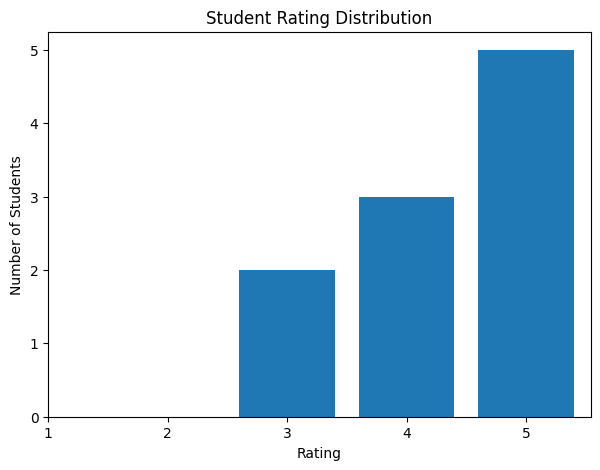

In [125]:
import matplotlib.pyplot as plt

# Count each rating
rating_counts = df["Rating"].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(7, 5))
plt.bar(rating_counts.index, rating_counts.values)

# Chart labels
plt.title("Student Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Students")
plt.xticks([1, 2, 3, 4, 5])

# Show chart
plt.show()

In [126]:
!pip install textblob

In [127]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Feedback"].apply(get_sentiment)

df[["Feedback", "Sentiment"]]

,Feedback,Sentiment
0,Very useful and interesting event,Positive
1,Excellent workshop and learned a lot,Positive
2,Enjoyed the cultural event,Positive
3,Very informative and practical,Positive
4,Event was okay but could be better,Positive
5,Good technical sessions,Positive
6,Amazing workshop and very useful,Positive
7,Nice performance and enjoyable,Positive
8,Excellent coding practice,Positive
9,Good event but needs improvement,Positive


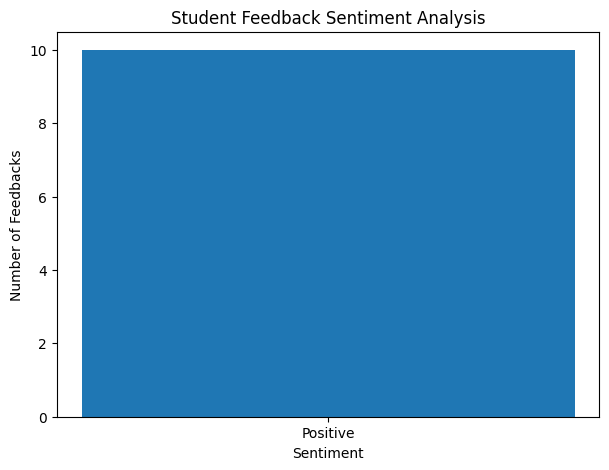

In [128]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Student Feedback Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedbacks")

plt.show()

In [129]:
event_rating = df.groupby("Event_Name")["Rating"].mean().sort_values(ascending=False)

print("Average Rating by Event:")
print(event_rating)

Average Rating by Event:
Event_Name
AI Workshop        5.0
Coding Workshop    5.0
Tech Fest          4.5
Cultural Fest      4.0
Sports Day         3.0
Name: Rating, dtype: float64


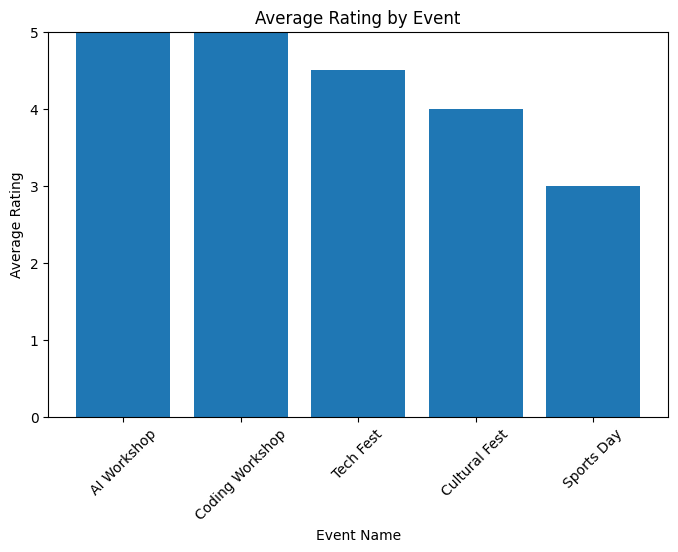

In [130]:
import matplotlib.pyplot as plt

event_rating = df.groupby("Event_Name")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(event_rating.index, event_rating.values)

plt.title("Average Rating by Event")
plt.xlabel("Event Name")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=45)

plt.show()

In [131]:
department_rating = df.groupby("Department")["Rating"].mean().sort_values(ascending=False)

print("Average Rating by Department:")
print(department_rating)

Average Rating by Department:
Department
IT      5.000000
CSE     4.750000
ECE     3.666667
MECH    3.000000
Name: Rating, dtype: float64


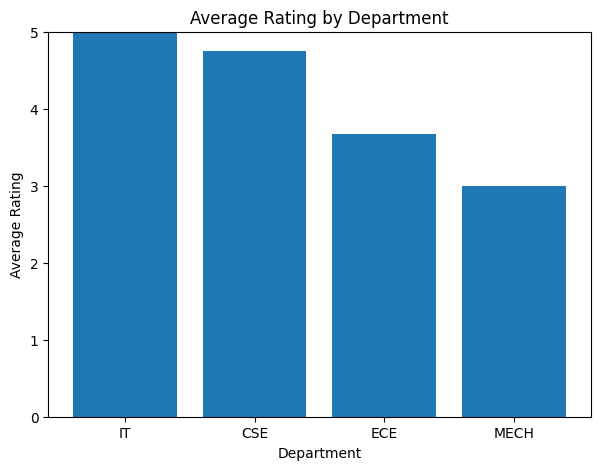

In [132]:
import matplotlib.pyplot as plt

department_rating = df.groupby("Department")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
plt.bar(department_rating.index, department_rating.values)

plt.title("Average Rating by Department")
plt.xlabel("Department")
plt.ylabel("Average Rating")
plt.ylim(0, 5)

plt.show()

In [133]:
!pip install wordcloud

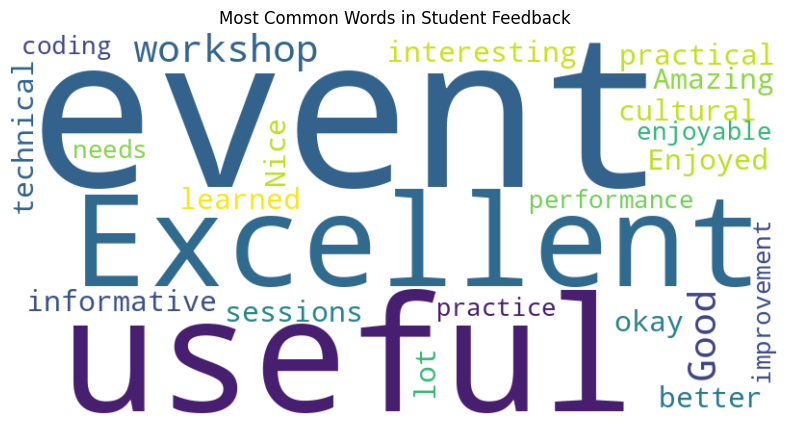

In [134]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all feedback comments
text = " ".join(df["Feedback"])

# Create word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

# Display word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Student Feedback")

plt.show()

In [135]:
print("KEY INSIGHTS")
print("-----------------------------")

print("1. Overall average rating:", df["Rating"].mean())

top_event = df.groupby("Event_Name")["Rating"].mean().idxmax()
print("2. Highest-rated event:", top_event)

top_department = df.groupby("Department")["Rating"].mean().idxmax()
print("3. Highest-rated department:", top_department)

most_common_sentiment = df["Sentiment"].value_counts().idxmax()
print("4. Most common sentiment:", most_common_sentiment)

print("\nRECOMMENDATIONS")
print("-----------------------------")
print("1. Continue organizing practical and informative workshops.")
print("2. Improve events with lower ratings by collecting student suggestions.")
print("3. Include more interactive activities in future events.")
print("4. Use student feedback to improve event planning.")

KEY INSIGHTS
-----------------------------
1. Overall average rating: 4.3
2. Highest-rated event: AI Workshop
3. Highest-rated department: IT
4. Most common sentiment: Positive

RECOMMENDATIONS
-----------------------------
1. Continue organizing practical and informative workshops.
2. Improve events with lower ratings by collecting student suggestions.
3. Include more interactive activities in future events.
4. Use student feedback to improve event planning.


# College Event Feedback Analysis

## Project Overview
This project analyzes student feedback collected after college events.

## Objectives
- Clean and prepare feedback data
- Analyze student ratings
- Perform sentiment analysis on feedback comments
- Visualize event and department-wise ratings
- Identify common words in student feedback
- Provide recommendations for future events

## Key Findings
- Overall average rating: 4.3
- Highest-rated events include AI Workshop and Coding Workshop
- IT department received the highest average rating
- Most feedback was positive
- Students appreciated useful, informative, and practical events

## Recommendations
- Organize more practical and informative workshops
- Improve events with lower ratings
- Include more interactive activities
- Collect student suggestions after every event
- Use feedback to improve future event planning

## Conclusion
The analysis shows that students generally had a positive experience with college events. Feedback and ratings can help organizers improve future events and increase student satisfaction.